In [31]:
import numpy as np
import pandas as pd

In [32]:
df=pd.read_csv('../Data/email.csv')
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [33]:
df.shape

(5573, 2)

In [34]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [35]:
df.duplicated().sum()

np.int64(415)

In [36]:
df.drop_duplicates(keep='first',inplace=True)
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='count', ylabel='Category'>

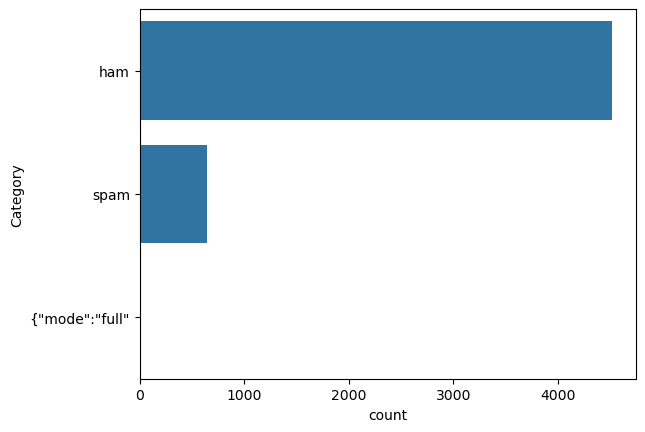

In [37]:
import seaborn as sns
sns.countplot(df['Category'])

In [9]:
#Data is imbalanced
!pip install nltk

In [11]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\katta\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [38]:
df['Category'].unique()

array(['ham', 'spam', '{"mode":"full"'], dtype=object)

In [39]:
df = df[df["Category"].isin(["ham", "spam"])]

In [40]:
df['character_count']=df['Message'].apply(len)

In [41]:
df.head()

,Category,Message,character_count
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [42]:
nltk.download('punkt_tab')
df['Message'].apply(lambda x: nltk.word_tokenize(x))

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\katta\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


0       [Go, until, jurong, point, ,, crazy, .., Avail...
1                [Ok, lar, ..., Joking, wif, u, oni, ...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor, ..., U, c, alrea...
4       [Nah, I, do, n't, think, he, goes, to, usf, ,,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568      [Will, ü, b, going, to, esplanade, fr, home, ?]
5569    [Pity, ,, *, was, in, mood, for, that, ., So, ...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                  [Rofl, ., Its, true, to, its, name]
Name: Message, Length: 5157, dtype: object

In [43]:
df['word_count']=df['Message'].apply(lambda x:len(nltk.word_tokenize(x)))
df['sent_count']=df['Message'].apply(lambda x:len(nltk.sent_tokenize(x)))
df.head()

,Category,Message,character_count,word_count,sent_count
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [44]:
df.describe()

,character_count,word_count,sent_count
count,5157.000000,5157.000000,5157.000000
mean,79.103936,18.560403,1.969750
std,58.382922,13.405970,1.455526
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.000000
75%,118.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


<Axes: xlabel='character_count', ylabel='Count'>

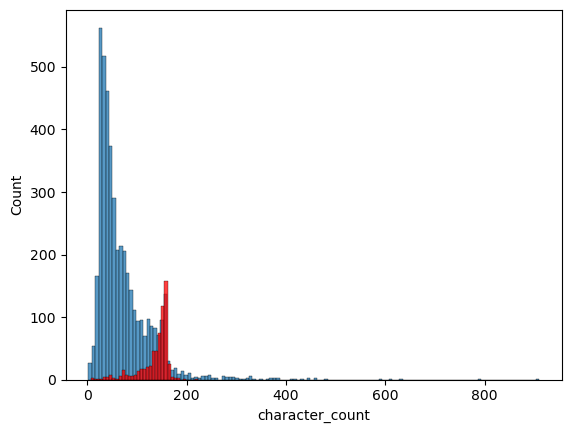

In [45]:
import seaborn as sns
sns.histplot(df[df['Category']=='ham']['character_count'])
sns.histplot(df[df['Category']=='spam']['character_count'],color='red')

<Axes: xlabel='word_count', ylabel='Count'>

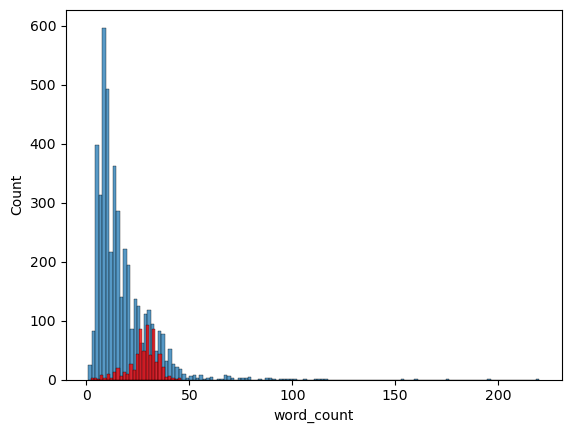

In [46]:
sns.histplot(df[df['Category']=='ham']['word_count'])
sns.histplot(df[df['Category']=='spam']['word_count'],color='red')

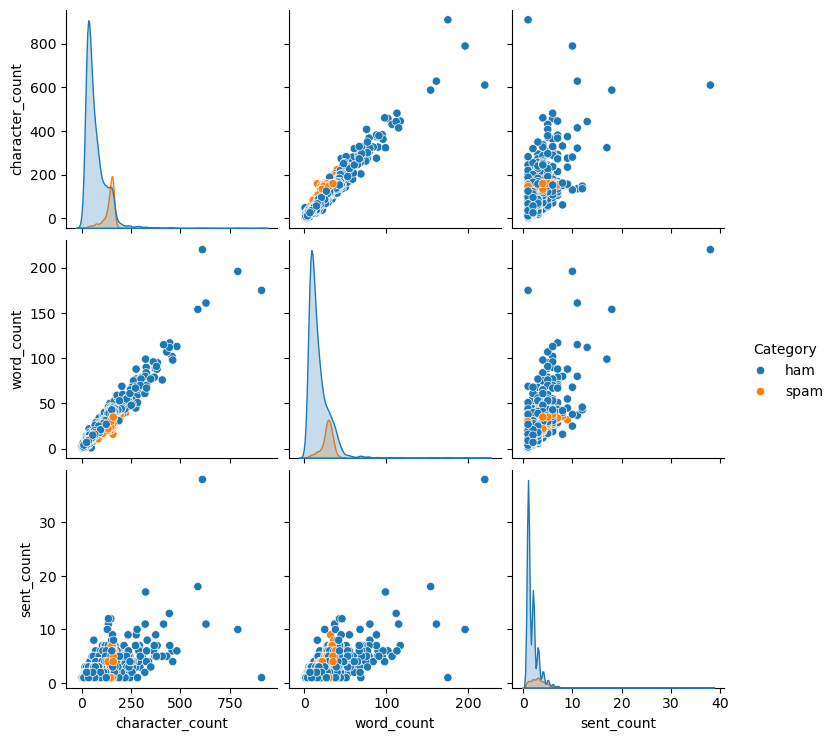

In [47]:
sns.pairplot(df,hue='Category')

<Axes: >

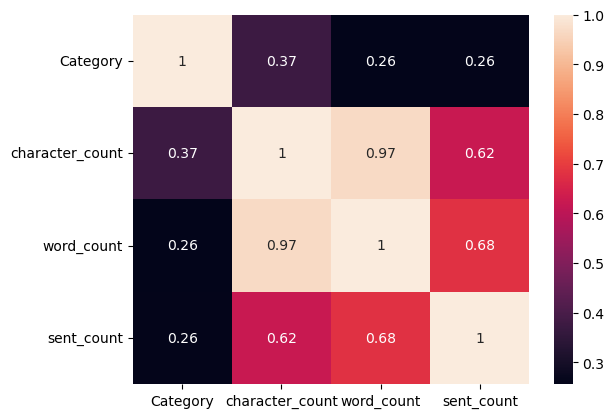

In [51]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['Category']=encoder.fit_transform(df['Category'])
sns.heatmap(df[['Category','character_count','word_count','sent_count']].corr(),annot=True)